In [4]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (8,926 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126111 files and dire

['NanumBarunGothic', 'NanumGothic', 'NanumGothicCoding', 'NanumMyeongjo', 'NanumSquare', 'NanumSquareRound']


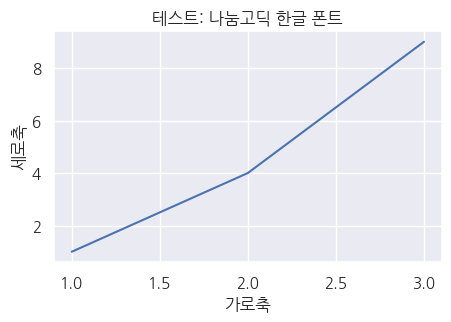

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 설치된 한글 폰트 확인 (NanumGothic, NanumBarunGothic 등 있을 수 있음)
print(sorted({f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name}))

# 대표 폰트로 NanumGothic (없으면 NanumBarunGothic 사용)
plt.rc('font', family='NanumGothic')     # 만약 없으면 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set(font='NanumGothic', rc={'axes.unicode_minus':False})

# 테스트
plt.figure(figsize=(5,3))
plt.title('테스트: 나눔고딕 한글 폰트')
plt.plot([1, 2, 3], [1, 4, 9])
plt.xlabel('가로축')
plt.ylabel('세로축')
plt.show()


LinearRegression → RMSE: 73589, R²: 0.138, F1: 0.737


<ipython-input-4-1654900972>:94: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_tr), np.log1p(y_tr_pred),
<ipython-input-4-1654900972>:96: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_te), np.log1p(y_te_pred),


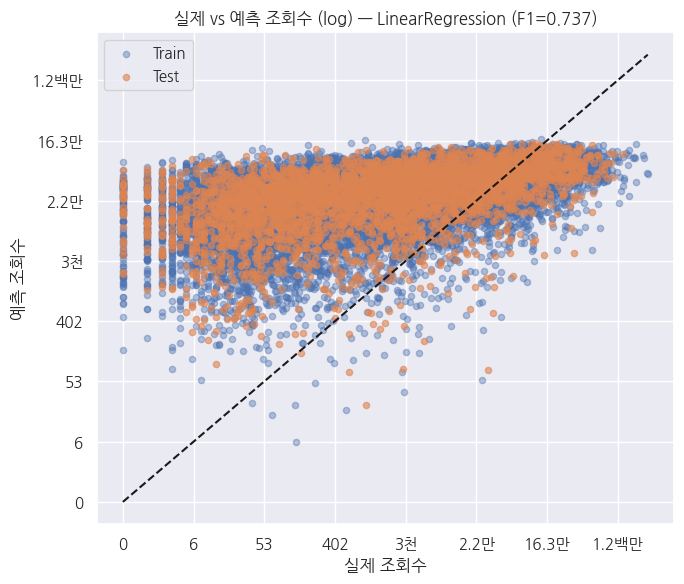

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2765
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 39
[LightGBM] [Info] Start training from score 25682.064508


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-4-1654900972>:94: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_tr), np.log1p(y_tr_pred),
<ipython-input-4-1654900972>:96: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_te), np.log1p(y_te_pred),


LightGBM        → RMSE: 65212, R²: 0.323, F1: 0.731


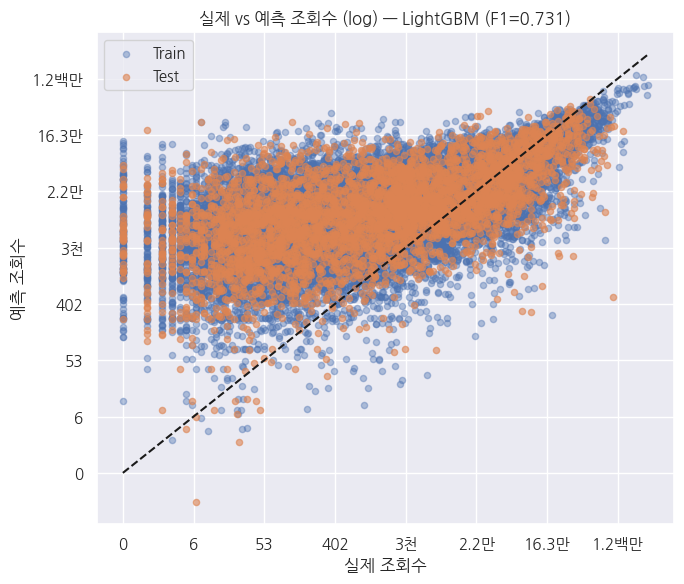

In [4]:
#1. 베이스라인 모델 결과 / 2. LightGBM 모델 결과
import os
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 0) 데이터 불러오기
file_path = 'final_data_챕터유무추가.csv'
df = pd.read_csv(file_path, encoding='cp949')

# 1) 전처리 함수
def categorize_hour(hour):
    try:
        h = int(hour)
        if   6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else:              return '새벽'
    except:
        return np.nan

df['시간대']       = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무']     = df['URL_유무'].map({True:'있음', False:'없음'})

# 2) 피처/타깃 정의
feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '텍스트_개수', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_구간평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일','시간대','주요_감정','URL_유무']

# 3) train/test split
data = df[feature_cols + [target_col]].dropna()
X_train, X_test, y_train, y_test = train_test_split(
    data[feature_cols], data[target_col],
    test_size=0.2, random_state=42
)

# 4) 전처리 & 모델 준비
preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

common_params = {
    'n_estimators': 262,
    'learning_rate': 0.012511752003328859,
    'max_depth': 12,
    'num_leaves': 94,
    'min_child_samples': 9,
    'subsample': 0.47024020985656356,
    'colsample_bytree': 0.6966521828215488,
    'random_state': 42
}

models = {
    'LinearRegression': Pipeline([
        ('prep', preprocessor),
        ('lr', LinearRegression())
    ]),
    'LightGBM': Pipeline([
        ('prep', preprocessor),
        ('lgbm', LGBMRegressor())
    ]),
}

# 5) 시각화 함수
def format_log_ticks(val, pos):
    true = np.expm1(val)
    if true >= 1e6: return f"{true/1e6:.1f}백만"
    if true >= 1e4: return f"{true/1e4:.1f}만"
    if true >= 1e3: return f"{true/1e3:.0f}천"
    return f"{int(true)}"

def plot_compare(y_tr, y_tr_pred, y_te, y_te_pred, title, f1=None):
    plt.figure(figsize=(7,6))
    plt.scatter(np.log1p(y_tr), np.log1p(y_tr_pred),
                alpha=0.4, label='Train', s=20)
    plt.scatter(np.log1p(y_te), np.log1p(y_te_pred),
                alpha=0.6, label='Test', s=20)
    mn = min(np.log1p(y_tr.min()), np.log1p(y_te.min()))
    mx = max(np.log1p(y_tr.max()), np.log1p(y_te.max()))
    plt.plot([mn,mx],[mn,mx],'k--')
    title_full = f"{title} (F1={f1:.3f})" if f1 is not None else title
    plt.title(f'실제 vs 예측 조회수 (log) — {title_full}')
    plt.xlabel('실제 조회수'); plt.ylabel('예측 조회수')
    plt.legend(); plt.grid(True)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    plt.tight_layout()
    plt.show()

# 6) 학습·평가·그래프 + F1 스코어
threshold = np.median(y_train)

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_tr_pred = pipe.predict(X_train)
    y_te_pred = pipe.predict(X_test)

    # 회귀 지표
    rmse = np.sqrt(mean_squared_error(y_test, y_te_pred))
    r2   = r2_score(y_test, y_te_pred)

    # 이진 분류 & F1
    y_te_true_class = (y_test  >= threshold).astype(int)
    y_te_pred_class = (y_te_pred >= threshold).astype(int)
    f1 = f1_score(y_te_true_class, y_te_pred_class)

    print(f"{name:15s} → RMSE: {rmse:.0f}, R²: {r2:.3f}, F1: {f1:.3f}")
    plot_compare(y_train, y_tr_pred, y_test, y_te_pred, title=name, f1=f1)


In [5]:
#3. 하이퍼 파라미터 튜닝 및 선정 과정 & 목록
import os
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint, uniform

# --- 데이터 로드 & 전처리 (기존 코드와 동일) ---
file_path = 'final_data_챕터유무추가.csv'
df = pd.read_csv(file_path, encoding='cp949')

def categorize_hour(hour):
    try:
        h = int(hour)
        if 6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else: return '새벽'
    except:
        return np.nan

df['시간대'] = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무'] = df['URL_유무'].map({True:'있음', False:'없음'})

feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일', '시간대', '주요_감정', 'URL_유무']

X = df[feature_cols].dropna()
y = df.loc[X.index, target_col]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 파이프라인 정의 ---
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(random_state=42))
])

# --- 하이퍼파라미터 탐색범위 정의 ---
param_distributions = {
    'lgbm__n_estimators': randint(100, 1500),
    'lgbm__learning_rate': uniform(0.001, 0.5),
    'lgbm__max_depth': randint(3, 15),
    'lgbm__num_leaves': randint(20, 200),
    'lgbm__min_child_samples': randint(5, 50),
    'lgbm__subsample': uniform(0.4, 0.6),
    'lgbm__colsample_bytree': uniform(0.4, 0.6),
}

# --- RandomizedSearchCV 설정 & 학습 ---
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=300,              # 시도할 파라미터 조합 수
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best RMSE:", -search.best_score_)
print("Best Params:", search.best_params_)

# --- 최적 모델로 평가 (수정) ---
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

# squared=False 대신 직접 sqrt 사용
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"Test set RMSE: {rmse:.0f}, R²: {r2:.3f}")


Fitting 3 folds for each of 300 candidates, totalling 900 fits


KeyboardInterrupt: 

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016440 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2765
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 39
[LightGBM] [Info] Start training from score 25682.064508


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


회귀 결과 → RMSE: 63536, R²: 0.357
이진 분류 F1 스코어 (threshold=565): 0.732


<ipython-input-5-2097549958>:102: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_tr), np.log1p(y_tr_pred), alpha=0.4, label='Train')
<ipython-input-5-2097549958>:103: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_te), np.log1p(y_te_pred), alpha=0.7, label='Test')


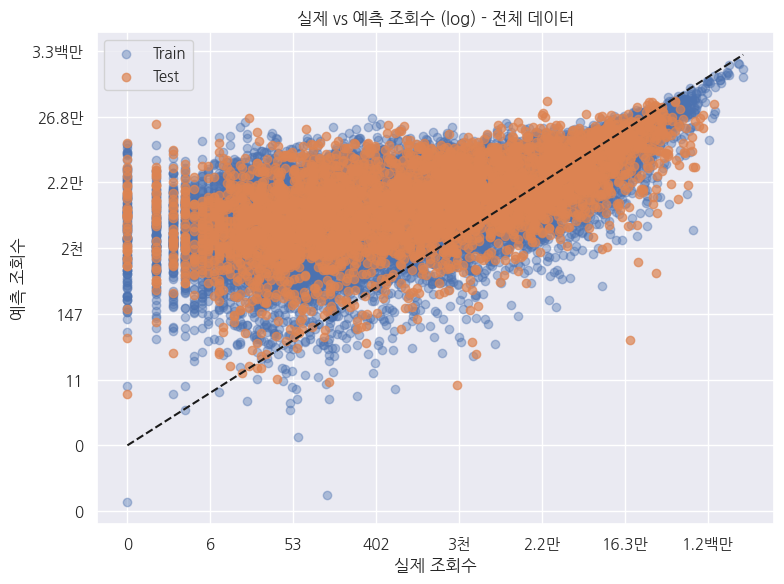

In [5]:
# 4. LightGBM 튜닝 결과 반영
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import matplotlib.ticker as ticker

# 0) 파일 로드
file_path = 'final_data_챕터유무추가.csv'
df = pd.read_csv(file_path, encoding='cp949')

# 1) 전처리
def categorize_hour(hour):
    try:
        h = int(hour)
        if   6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else:              return '새벽'
    except:
        return np.nan

df['시간대']       = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무']     = df['URL_유무'].map({True:'있음', False:'없음'})

feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '텍스트_개수', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_구간평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일', '시간대', '주요_감정', 'URL_유무']

# 2) train/test split
full = df[feature_cols + [target_col]].dropna()
X_train, X_test, y_train, y_test = train_test_split(
    full[feature_cols], full[target_col],
    test_size=0.2, random_state=42
)

# 3) 파이프라인 + 최적 하이퍼파라미터 적용
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

model = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(
        n_estimators=1030,
        learning_rate=0.012446912488060125,
        max_depth=13,
        num_leaves=39,
        min_child_samples=6,
        subsample=0.7438248573585096,
        colsample_bytree=0.5935167867078491,
        random_state=42
    ))
])

# 4) 학습 & 예측
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# 5) 회귀 지표
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2   = r2_score(y_test, y_test_pred)
print(f"회귀 결과 → RMSE: {rmse:.0f}, R²: {r2:.3f}")

# 6) 이진 분류 레이블 생성 (기준: y_train 중앙값)
threshold = np.median(y_train)
y_true_class = (y_test  >= threshold).astype(int)
y_pred_class = (y_test_pred >= threshold).astype(int)

# 7) F1 스코어 계산
f1 = f1_score(y_true_class, y_pred_class)
print(f"이진 분류 F1 스코어 (threshold={int(threshold)}): {f1:.3f}")

# 8) 시각화 함수 & 그래프
def format_log_ticks(val, pos):
    true = np.expm1(val)
    if true >= 1e6: return f"{true/1e6:.1f}백만"
    if true >= 1e4: return f"{true/1e4:.1f}만"
    if true >= 1e3: return f"{true/1e3:.0f}천"
    return f"{int(true)}"

def plot_compare(y_tr, y_tr_pred, y_te, y_te_pred, title_tag):
    plt.figure(figsize=(8,6))
    plt.scatter(np.log1p(y_tr), np.log1p(y_tr_pred), alpha=0.4, label='Train')
    plt.scatter(np.log1p(y_te), np.log1p(y_te_pred), alpha=0.7, label='Test')
    mn = min(np.log1p(y_tr).min(), np.log1p(y_te).min())
    mx = max(np.log1p(y_tr).max(), np.log1p(y_te).max())
    plt.plot([mn, mx], [mn, mx], 'k--')
    plt.title(f'실제 vs 예측 조회수 (log) - {title_tag}')
    plt.xlabel('실제 조회수'); plt.ylabel('예측 조회수')
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plot_compare(y_train, y_train_pred, y_test, y_test_pred, title_tag="전체 데이터")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007680 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2765
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 39
[LightGBM] [Info] Start training from score 25682.064508


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


회귀 결과 → RMSE: 63536, R²: 0.357
이진 분류 F1 스코어 (threshold=565): 0.732


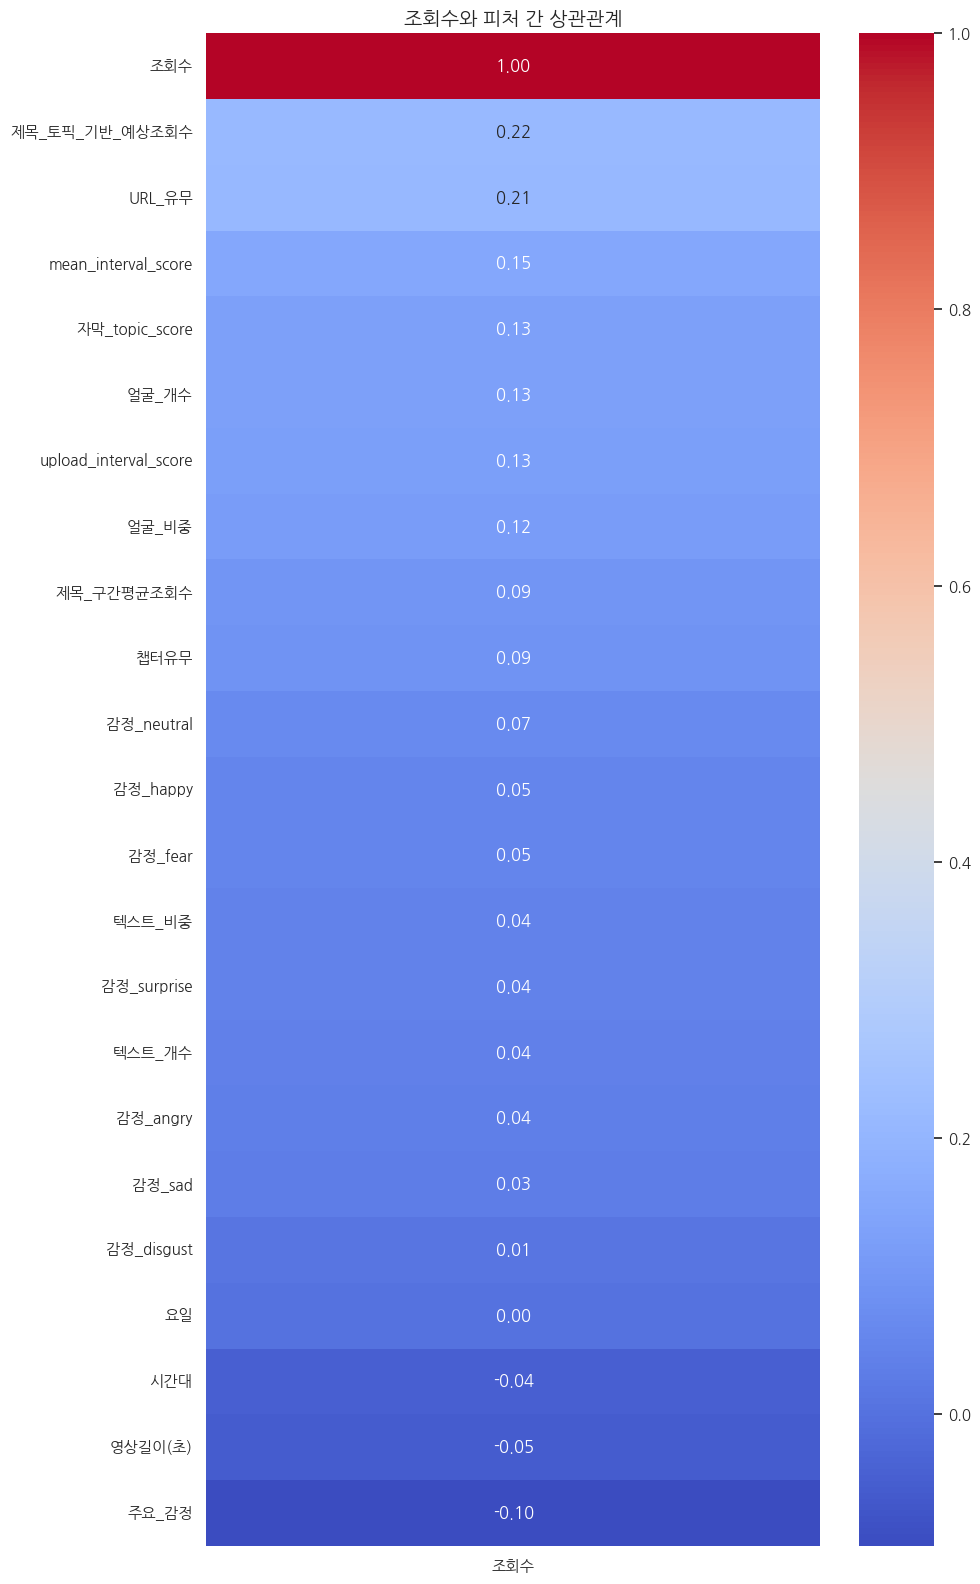

<ipython-input-7-2067830849>:106: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_tr), np.log1p(y_tr_pred), alpha=0.4, label='Train')
<ipython-input-7-2067830849>:107: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_te), np.log1p(y_te_pred), alpha=0.7, label='Test')


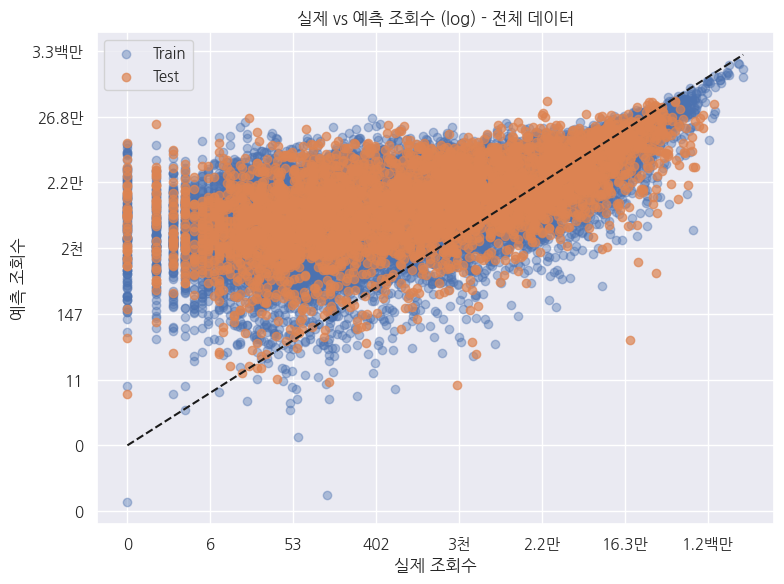

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import matplotlib.ticker as ticker
import seaborn as sns

# 0) 파일 로드
file_path = 'final_data_챕터유무추가.csv'
df = pd.read_csv(file_path, encoding='cp949')

# 1) 전처리: 시간대 분류, 얼굴/URL 이진화
def categorize_hour(hour):
    try:
        h = int(hour)
        if   6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else:              return '새벽'
    except:
        return np.nan

df['시간대']       = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무']     = df['URL_유무'].map({True:'있음', False:'없음'})

# 2) 피처·타깃 정의
feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '텍스트_개수', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_구간평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일', '시간대', '주요_감정', 'URL_유무']


# 2) train/test split
full = df[feature_cols + [target_col]].dropna()
X = full[feature_cols]
y = full[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) 파이프라인 + 최적 하이퍼파라미터 적용
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

model = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(
        n_estimators=1030,
        learning_rate=0.012446912488060125,
        max_depth=13,
        num_leaves=39,
        min_child_samples=6,
        subsample=0.7438248573585096,
        colsample_bytree=0.5935167867078491,
        random_state=42
    ))
])

# 4) 학습 & 예측
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# 5) 회귀 지표 (squared 인자 제거 후 np.sqrt 사용)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2   = r2_score(y_test, y_test_pred)
print(f"회귀 결과 → RMSE: {rmse:.0f}, R²: {r2:.3f}")

# 6) 이진 분류 레이블 생성 (기준: y_train 중앙값)
threshold = np.median(y_train)
y_true_class = (y_test  >= threshold).astype(int)
y_pred_class = (y_test_pred >= threshold).astype(int)

# 7) F1 스코어 계산
f1 = f1_score(y_true_class, y_pred_class)
print(f"이진 분류 F1 스코어 (threshold={int(threshold)}): {f1:.3f}")

# 8) 시각화 함수
def format_log_ticks(val, pos):
    true = np.expm1(val)
    if true >= 1e6: return f"{true/1e6:.1f}백만"
    if true >= 1e4: return f"{true/1e4:.1f}만"
    if true >= 1e3: return f"{true/1e3:.0f}천"
    return f"{int(true)}"

def plot_compare(y_tr, y_tr_pred, y_te, y_te_pred, title_tag):
    plt.figure(figsize=(8,6))
    plt.scatter(np.log1p(y_tr), np.log1p(y_tr_pred), alpha=0.4, label='Train')
    plt.scatter(np.log1p(y_te), np.log1p(y_te_pred), alpha=0.7, label='Test')
    mn = min(np.log1p(y_tr).min(), np.log1p(y_te).min())
    mx = max(np.log1p(y_tr).max(), np.log1p(y_te).max())
    plt.plot([mn, mx], [mn, mx], 'k--')
    plt.title(f'실제 vs 예측 조회수 (log) - {title_tag}')
    plt.xlabel('실제 조회수'); plt.ylabel('예측 조회수')
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    plt.legend(), plt.grid(True); plt.tight_layout(); plt.show()

# 9) 상관관계 시각화 (범주형 변수는 숫자형으로 변환 필요)
df_corr = full.copy()

# Label Encoding → 범주형 변수들
from sklearn.preprocessing import LabelEncoder
for col in categorical_features:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# 상관계수 계산 및 히트맵
corr_matrix = df_corr[feature_cols + [target_col]].corr()

plt.figure(figsize=(10, 16))
sns.heatmap(corr_matrix[[target_col]].sort_values(by=target_col, ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("조회수와 피처 간 상관관계", fontsize=14)
plt.tight_layout()
plt.show()

plot_compare(y_train, y_train_pred, y_test, y_test_pred, title_tag="전체 데이터")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3074
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 42
[LightGBM] [Info] Start training from score 25682.064508
회귀 결과 → RMSE: 62563, R²: 0.377
이진 분류 F1 스코어 (threshold=565): 0.736


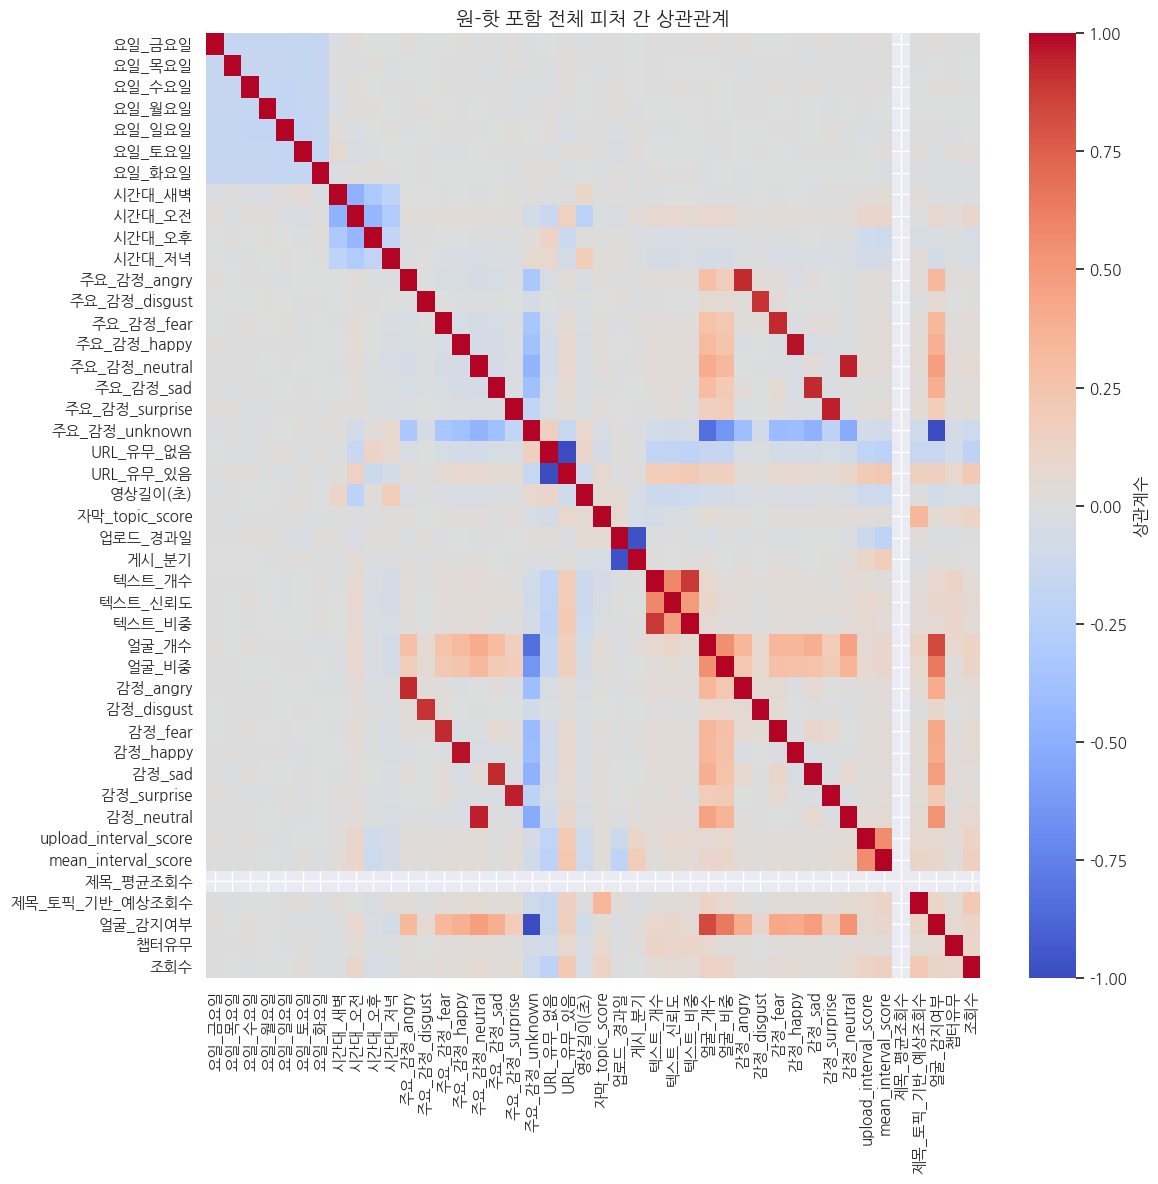

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import matplotlib.ticker as ticker

# 0) 파일 로드
file_path = 'final_data_챕터유무추가.csv'
df = pd.read_csv(file_path, encoding='UTF-8-SIG')

# 1) 전처리: 시간대 분류, 얼굴/URL 이진화
def categorize_hour(hour):
    try:
        h = int(hour)
        if   6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else:              return '새벽'
    except:
        return np.nan

df['시간대']       = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무']     = df['URL_유무'].map({True:'있음', False:'없음'})

# 2) 피처·타깃 정의
feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일', '시간대', '주요_감정', 'URL_유무']

# 3) 학습/테스트 분할
data = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
X = data[feature_cols]
y = data[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) 전처리기 & 모델 파이프라인 (튜닝 파라미터 적용)
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

tuned_params = {
    'n_estimators': 1030,
    'learning_rate': 0.012446912488060125,
    'max_depth': 13,
    'num_leaves': 39,
    'min_child_samples': 6,
    'subsample': 0.7438248573585096,
    'colsample_bytree': 0.5935167867078491,
    'random_state': 42
}

model = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(**tuned_params))
])

# 5) 학습 & 예측
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# 6) 회귀 성능 지표
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2   = r2_score(y_test, y_test_pred)
print(f"회귀 결과 → RMSE: {rmse:.0f}, R²: {r2:.3f}")

# 7) 간단 이진 분류 F1 스코어
threshold      = np.median(y_train)
y_true_class   = (y_test >= threshold).astype(int)
y_pred_class   = (y_test_pred >= threshold).astype(int)
f1             = f1_score(y_true_class, y_pred_class)
print(f"이진 분류 F1 스코어 (threshold={int(threshold)}): {f1:.3f}")

# 9) 상관관계 시각화 (원-핫 포함 전체 피처)
from sklearn.preprocessing import OneHotEncoder

# (1) 원-핫 인코딩
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
dummies = ohe.fit_transform(full[categorical_features])
dummy_cols = ohe.get_feature_names_out(categorical_features)

# (2) 더미 DF + 수치형 DF + 타깃 결합
df_dummies = pd.DataFrame(dummies, columns=dummy_cols, index=full.index)
df_numeric = full.drop(columns=categorical_features + [target_col])
encoded_df = pd.concat([df_dummies, df_numeric, full[[target_col]]], axis=1)

# (3) 상관계수 계산
corr_matrix = encoded_df.corr()

# (4) 히트맵 그리기
plt.figure(figsize=(12, 12))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    cbar_kws={'label': '상관계수'}
)
plt.title("원-핫 포함 전체 피처 간 상관관계", fontsize=14)
plt.tight_layout()
plt.show()


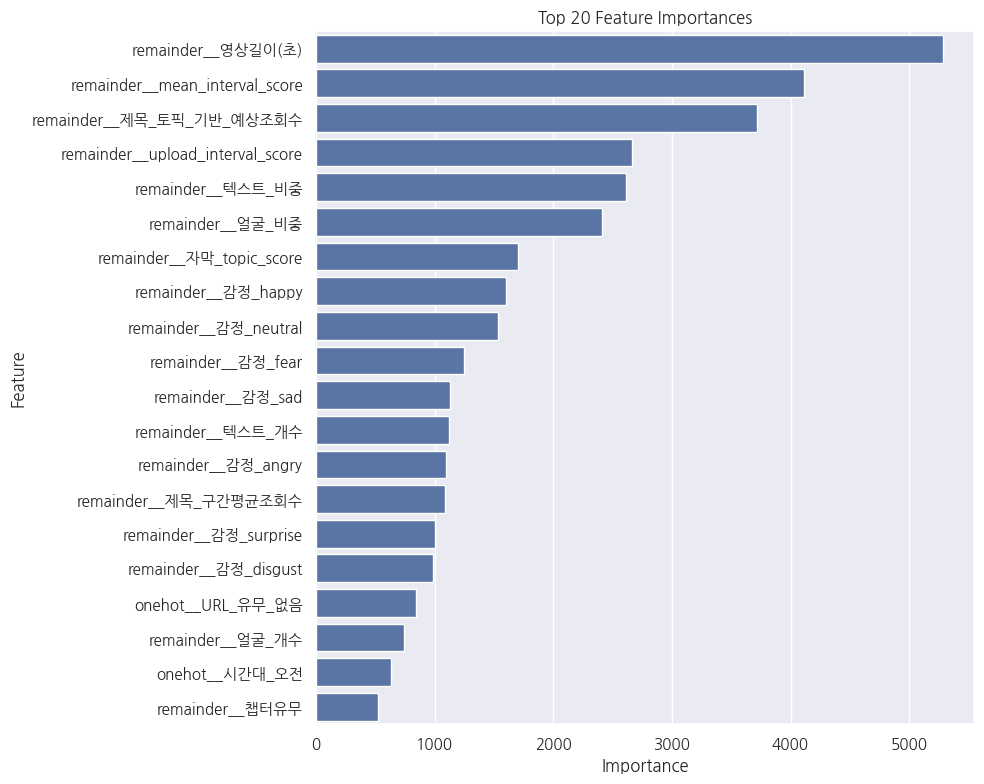

In [8]:
# 9) 피처 중요도 시각화
import seaborn as sns

# (1) 전처리된 피처 이름 얻기
#    ColumnTransformer + OneHotEncoder를 쓴 경우 get_feature_names_out() 호출
feature_names = model.named_steps['prep'].get_feature_names_out()

# (2) LightGBM에서 중요도 뽑기
importances = model.named_steps['lgbm'].feature_importances_

# (3) Series로 정리하고 내림차순 정렬
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# (4) 상위 20개 피처 그리기
plt.figure(figsize=(10, 8))
sns.barplot(x=feat_imp.values[:20], y=feat_imp.index[:20])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [9]:
# ── 파일 업로드(Colab UI) 또는 경로 지정 ────────────────────
# ① 직접 업로드하려면:
'''from google.colab import files
uploaded = files.upload()                 # 예: test_data.xlsx 업로드
test_file = next(iter(uploaded)) '''         # 첫 번째 업로드 파일명

# ② 이미 런타임에 파일이 있다면:
test_file = 'test_data.xlsx'

# ── 읽기 (확장자 자동 판별) ────────────────────────────────
import pandas as pd, numpy as np, re, os, pathlib

suffix = pathlib.Path(test_file).suffix.lower()
if suffix in ['.xlsx', '.xls']:
    test_df = pd.read_excel(test_file)           # Excel
else:
    test_df = pd.read_csv(test_file, encoding='utf-8-sig')  # CSV
'''
# ── 학습 데이터와 동일한 파생 컬럼 만들기 ───────────────────
# 1) URL_유무 (정수 1/0)
url_pattern   = re.compile(r'https?://', flags=re.IGNORECASE)
test_df['URL_유무'] = (
    test_df['영상설명'].fillna('')
           .apply(lambda x: bool(url_pattern.search(x)))
           .map({True: 1, False: 0})
           .astype(int)
)

# 2) 시간대
def categorize_hour(hour):
    try:
        h = int(hour)
        if   6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else:              return '새벽'
    except: return np.nan
test_df['시간대'] = test_df['업로드_시각'].apply(categorize_hour)

# 3) 얼굴_감지여부 int 형
if '얼굴_감지여부' in test_df.columns:
    test_df['얼굴_감지여부'] = test_df['얼굴_감지여부'].astype(int)

# ── (선택) 컬럼 순서 정렬: 훈련 feature_cols 와 맞추기 ───────
required_cols = [c for c in feature_cols if c in test_df.columns]
missing       = [c for c in feature_cols if c not in test_df.columns]
if missing:
    print("🚨 테스트 데이터에 없는 컬럼:", missing)

test_df = test_df[ required_cols + [target] ]  # 순서 맞추기
print("✓ test_df 준비 완료 :", test_df.shape)
'''

'\n# ── 학습 데이터와 동일한 파생 컬럼 만들기 ───────────────────\n# 1) URL_유무 (정수 1/0)\nurl_pattern   = re.compile(r\'https?://\', flags=re.IGNORECASE)\ntest_df[\'URL_유무\'] = (\n    test_df[\'영상설명\'].fillna(\'\')\n           .apply(lambda x: bool(url_pattern.search(x)))\n           .map({True: 1, False: 0})\n           .astype(int)\n)\n\n# 2) 시간대\ndef categorize_hour(hour):\n    try:\n        h = int(hour)\n        if   6 <= h < 12: return \'오전\'\n        elif 12 <= h < 18: return \'오후\'\n        elif 18 <= h < 24: return \'저녁\'\n        else:              return \'새벽\'\n    except: return np.nan\ntest_df[\'시간대\'] = test_df[\'업로드_시각\'].apply(categorize_hour)\n\n# 3) 얼굴_감지여부 int 형\nif \'얼굴_감지여부\' in test_df.columns:\n    test_df[\'얼굴_감지여부\'] = test_df[\'얼굴_감지여부\'].astype(int)\n\n# ── (선택) 컬럼 순서 정렬: 훈련 feature_cols 와 맞추기 ───────\nrequired_cols = [c for c in feature_cols if c in test_df.columns]\nmissing       = [c for c in feature_cols if c not in test_df.columns]\nif missing:\n    print("🚨 테스트 데이터에 없는

RMSE : 34013.3
R²   : 0.001



<ipython-input-11-1190824621>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({True: 1, False: 0}).astype(int)
<ipython-input-11-1190824621>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({True: 1, False: 0}).astype(int)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,실제,예측,오차
0,9046,6075,2971
1,9045,55140,-46095
2,9037,28505,-19468
3,8996,12390,-3394
4,8994,16530,-7536
5,8981,10896,-1915
6,8981,38837,-29856
7,8980,22299,-13319
8,8968,113118,-104150
9,8946,45268,-36322


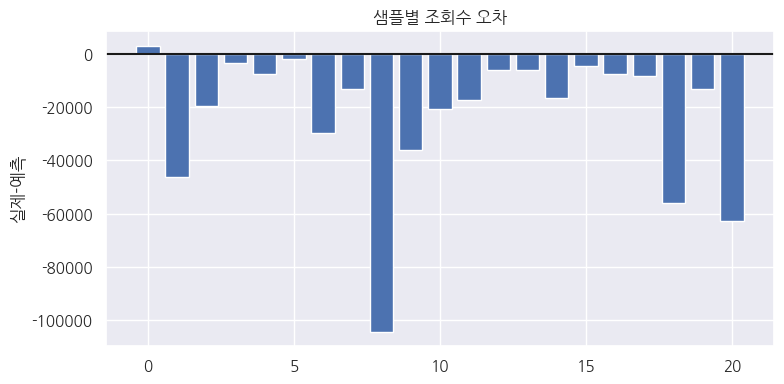

In [11]:
# 전제: model = Pipeline(prep + lgbm),  test_df = 조회수 포함 DataFrame

import pandas as pd, numpy as np, matplotlib.pyplot as plt

df = test_df.copy()

# 1) 학습 때 범주형이었던 컬럼 목록
cat_cols = ['요일', '시간대', '주요_감정', 'URL_유무']   # 학습·모델과 동일해야 함
target   = '조회수'

# 1-A. 불리언 → 0/1  (LightGBM은 int를 숫자로 처리)
for col in ['URL_유무', '얼굴_감지여부']:
    if col in df.columns:
        df[col] = df[col].replace({True: 1, False: 0}).astype(int)

# 1-B. 시간대 파생이 없으면 생성
if '시간대' not in df.columns and '업로드_시각' in df.columns:
    df['시간대'] = df['업로드_시각'].apply(
        lambda h: ('오전' if 6<=int(h)<12 else '오후' if 12<=int(h)<18
                   else '저녁' if 18<=int(h)<24 else '새벽')
                 if pd.notna(h) else np.nan
    )

# 2) ▶ 숫자 vs 범주 구분하여 dtype 통일
for c in df.columns:
    if c == target:
        continue
    if c in cat_cols:                 # 범주형 → 문자열 (One-Hot 대상)
        df[c] = df[c].astype('str')
    else:                             # 나머지 전부 float64
        df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')

# 3) ▶ 예측
y_true = df[target].to_numpy()
X      = df.drop(columns=[target])
y_pred = model.predict(X)

# 4) ▶ 차이·지표·그래프
diff   = y_true - y_pred
print(f"RMSE : {np.sqrt((diff**2).mean()):.1f}")
print(f"R²   : {np.corrcoef(y_true, y_pred)[0,1]**2:.3f}\n")

result = pd.DataFrame({'실제':y_true.astype(int),
                       '예측':y_pred.round().astype(int),
                       '오차':diff.round().astype(int)})
display(result)   # 상위 10행 확인

plt.figure(figsize=(8,4))
plt.bar(result.index, result['오차'])
plt.axhline(0,color='k'); plt.ylabel('실제-예측')
plt.title('샘플별 조회수 오차'); plt.tight_layout(); plt.show()

✓ 오차 최소 샘플 index=5, 게임명=nan


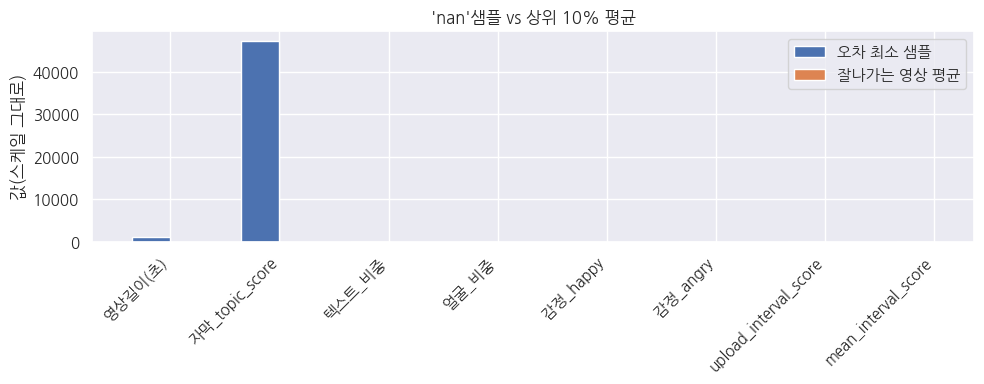

In [12]:
# 전제 : result  =  [실제, 예측, 오차] DataFrame (위에서 만든 것)
#        df      =  test_df 원본 + 파생컬럼까지 반영된 DataFrame
#        train_df=  전체 학습 데이터(같은 컬럼 구조)  ← 미리 로드돼 있다고 가정

import matplotlib.pyplot as plt
import numpy as np

# 1) ─ 오차가 가장 작은 샘플 찾기 ─────────────────────────────
best_idx   = result['오차'].abs().idxmin()
best_row   = df.loc[best_idx]
game_name  = best_row['게임명']
print(f"✓ 오차 최소 샘플 index={best_idx}, 게임명={game_name}")

# 2) ─ 동일 게임명의 '잘나가는' 영상 선정 ─────────────────────
subset     = df[ df['게임명'] == game_name ].copy()
top_cut    = subset['조회수'].quantile(0.9)
top_hits   = subset[ subset['조회수'] >= top_cut ]

# 3) ─ 비교할 주요 수치 피처 선택 ────────────────────────────
numeric_cols = ['영상길이(초)',
                '자막_topic_score',
                '텍스트_비중',
                '얼굴_비중',
                '감정_happy',
                '감정_angry',
                'upload_interval_score',
                'mean_interval_score']

best_vals = best_row[numeric_cols].astype(float)
mean_vals = top_hits[numeric_cols].mean()

# 4) ─ 단순 시각화 ─────────────────────────────────────────
x = np.arange(len(numeric_cols))
width = 0.35

plt.figure(figsize=(10,4))
plt.bar(x-width/2, best_vals, width, label='오차 최소 샘플')
plt.bar(x+width/2, mean_vals, width, label='잘나가는 영상 평균')
plt.xticks(x, numeric_cols, rotation=45, ha='right')
plt.ylabel('값(스케일 그대로)')
plt.title(f"'{game_name}'샘플 vs 상위 10% 평균")
plt.legend()
plt.tight_layout(); plt.show()


In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# 1) 테스트+파생 데이터프레임(df) 에서 비교할 행 지정
chosen_idx = [3, 4, 5, 7, 10, 15]
chosen_df  = df.loc[chosen_idx].copy()           # df = test_data + 파생 컬럼까지 반영

# 2) 비교할 피처 (※ 실제 컬럼 목록과 정확히 동일)
numeric_cols = [
    '영상길이(초)', '자막_topic_score', '텍스트_비중', '얼굴_비중',
    '감정_happy',  '감정_angry',
    'upload_interval_score', 'mean_interval_score'
]

# ── 존재하지 않는 컬럼 확인 (오타 방지) ───────────────────
missing = [c for c in numeric_cols if c not in df.columns]
if missing:
    raise ValueError(f"다음 컬럼이 df에 없습니다 → {missing}")

records = []
for idx, row in chosen_df.iterrows():
    gm = row['게임명']
    if pd.isna(gm):
        print(f"⚠️ idx {idx}: 게임명이 NaN → 건너뜀"); continue

    pool = df[df['게임명'] == gm]
    if pool.empty:
        print(f"⚠️ idx {idx}: '{gm}' 게임이 학습 데이터에 없음 → 건너뜀"); continue

    top_mean = (
        pool[ pool['조회수'] >= pool['조회수'].quantile(0.9) ][numeric_cols]
        .mean(numeric_only=True)
    )

    diff = row[numeric_cols].astype(float) - top_mean
    records.append({'index': idx, '게임명': gm, **diff.to_dict()})

if not records:
    raise RuntimeError("비교 가능한 샘플이 없습니다. 게임명·행 번호를 확인하세요.")

diff_df   = pd.DataFrame(records).set_index('index')
mean_diff = diff_df[numeric_cols].mean()        # 6개 샘플 평균 차이

# 3) 막대그래프 — 양수(초록)=선택 샘플이 더 많음 / 음수(빨강)=부족
x = np.arange(len(numeric_cols))
plt.figure(figsize=(10,4))
plt.bar(x, mean_diff,
        color=['#2ca02c' if v > 0 else '#d62728' for v in mean_diff])
plt.axhline(0, color='k')
plt.xticks(x, numeric_cols, rotation=45, ha='right')
plt.ylabel('선택 샘플 평균 − 상위10% 평균')
plt.title('선택 6개 샘플 vs 같은 게임 상위 10% 영상 평균')
plt.tight_layout(); plt.show()

# 4) 상세 차이표(행 × 변수) — 발표 슬라이드에 표로 복붙
display(diff_df[numeric_cols].round(2))


⚠️ idx 3: 게임명이 NaN → 건너뜀
⚠️ idx 4: 게임명이 NaN → 건너뜀
⚠️ idx 5: 게임명이 NaN → 건너뜀
⚠️ idx 7: 게임명이 NaN → 건너뜀
⚠️ idx 10: 게임명이 NaN → 건너뜀
⚠️ idx 15: 게임명이 NaN → 건너뜀


RuntimeError: 비교 가능한 샘플이 없습니다. 게임명·행 번호를 확인하세요.

<ipython-input-17-913596183>:51: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


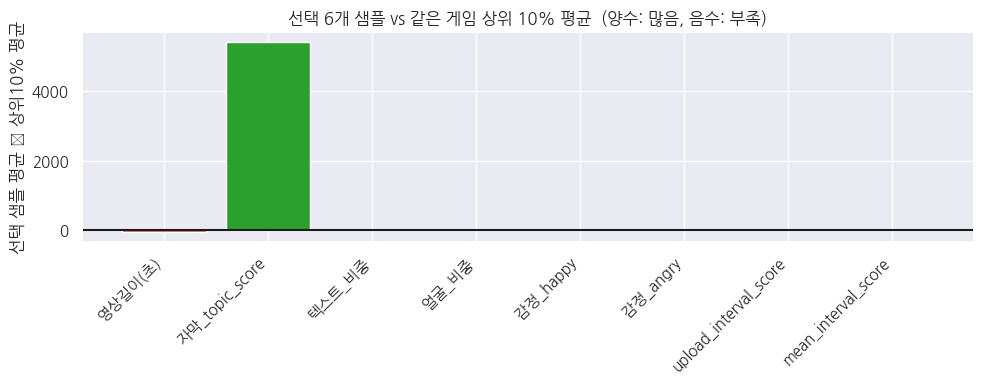

,영상길이(초),자막_topic_score,텍스트_비중,얼굴_비중,감정_happy,감정_angry,upload_interval_score,mean_interval_score
index,,,,,,,,
3,-256.67,-10859.41,0.17,-1.60,0.00,-0.19,1.09,-1.22
4,-116.67,21718.81,-1.68,-1.60,0.00,-0.19,1.42,0.92
5,411.33,-10859.41,-1.22,-1.60,0.00,-0.19,-1.47,-2.56
7,-135.67,21718.81,-1.10,2.39,0.09,2.72,-0.56,-1.22
10,-129.67,21718.81,-1.68,-1.60,0.00,-0.19,1.33,1.54
15,-121.67,-10859.41,0.29,-1.60,0.00,-0.19,1.10,0.92


In [17]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# 0) 테스트 파일 읽기 -- 확장자에 따라 자동
test_file = 'test_data.xlsx'         # 필요하면 경로 수정
if test_file.endswith(('.xls', '.xlsx')):
    test_df = pd.read_excel(test_file)
else:
    test_df = pd.read_csv(test_file, encoding='utf-8-sig')

df = test_df.copy()                  # 이후 코드에서 쓸 이름
numeric_cols = [
    '영상길이(초)', '자막_topic_score', '텍스트_비중', '얼굴_비중',
    '감정_happy',  '감정_angry',
    'upload_interval_score', 'mean_interval_score'
]

# 1) 비교할 행 미리 지정
chosen_idx = [3, 4, 5, 7, 10, 15]
chosen_df  = df.loc[chosen_idx]

records = []
for idx, row in chosen_df.iterrows():
    gm = row['게임명']
    if pd.isna(gm):
        print(f"⚠️ idx {idx}: 게임명이 NaN → 건너뜀"); continue

    pool = df[df['게임명'] == gm]                 # 같은 게임 (test_data 내부)
    top   = pool['조회수'].quantile(0.9)           # 상위 10 %
    top_mean = pool[ pool['조회수'] >= top ][numeric_cols].mean()

    if top_mean.isna().all():
        print(f"⚠️ idx {idx}: '{gm}' 게임 상위10%가 부족 → 건너뜀"); continue

    diff = row[numeric_cols].astype(float) - top_mean
    records.append({'index':idx, '게임명':gm, **diff.to_dict()})

if not records:
    raise RuntimeError("비교 가능한 샘플이 없습니다. 게임명·행 번호·컬럼 확인!")

diff_df   = pd.DataFrame(records).set_index('index')
mean_diff = diff_df[numeric_cols].mean()

# 2) 막대 그래프
x = np.arange(len(numeric_cols))
plt.figure(figsize=(10,4))
plt.bar(x, mean_diff, color=['#2ca02c' if v>0 else '#d62728' for v in mean_diff])
plt.axhline(0,color='k')
plt.xticks(x, numeric_cols, rotation=45, ha='right')
plt.ylabel('선택 샘플 평균 − 상위10% 평균')
plt.title('선택 6개 샘플 vs 같은 게임 상위 10% 평균  (양수: 많음, 음수: 부족)')
plt.tight_layout(); plt.show()

# 3) 상세 차이표 (발표용 표)
display(diff_df[numeric_cols].round(2))


In [16]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# 0) ─ 필요한 파생 컬럼 보정 ────────────────────────────────
df = df.copy()                     # test_df(또는 통합 DF)

if '시간대' not in df.columns and '업로드_시각' in df.columns:
    def h2t(h):
        try:
            h = int(h)
            return ('오전' if 6<=h<12 else
                    '오후' if 12<=h<18 else
                    '저녁' if 18<=h<24 else
                    '새벽')
        except: return np.nan
    df['시간대'] = df['업로드_시각'].apply(h2t)

# 1) ─ 모델 피처 목록에서 실제로 존재하는 것만 선택 ──────────
feature_cols = [
    '영상길이(초)','자막_topic_score','업로드_경과일','게시_분기',
    '텍스트_개수','텍스트_신뢰도','텍스트_비중',
    '얼굴_개수','얼굴_비중',
    '감정_angry','감정_disgust','감정_fear','감정_happy',
    '감정_sad','감정_surprise','감정_neutral',
    'upload_interval_score','mean_interval_score',
    '제목_평균조회수','제목_토픽_기반_예상조회수',
    '요일','시간대','주요_감정','얼굴_감지여부','챕터유무','URL_유무'
]

feature_cols = [c for c in feature_cols if c in df.columns]  # 존재하는 것만
numeric_cols = [c for c in feature_cols if df[c].dtype.kind in 'fi']
cat_cols     = [c for c in feature_cols if c not in numeric_cols]

# 2) ─ 비교 대상 행 (직접 지정) ─────────────────────────────
chosen_idx = [3,4,5,7,10,15]
chosen_df  = df.loc[chosen_idx]

records_num, records_cat = [], []

for idx, row in chosen_df.iterrows():
    gm = row['게임명']
    if pd.isna(gm):
        print(f"⚠️ idx {idx} 게임명 NaN → 건너뜀"); continue

    pool = df[df['게임명']==gm]
    if pool.empty:
        print(f"⚠️ idx {idx} '{gm}' 게임 데이터 없음 → 건너뜀"); continue

    top_pool = pool[pool['조회수'] >= pool['조회수'].quantile(0.9)]

    # 숫자형 차이
    top_mean_num = top_pool[numeric_cols].mean(numeric_only=True)
    diff_num = row[numeric_cols].astype(float) - top_mean_num
    records_num.append({'index':idx,'게임명':gm,**diff_num.to_dict()})

    # 문자형 비교(샘플 vs 모드)
    cat_row = {}
    for c in cat_cols:
        sample_val = row[c]
        mode_val   = top_pool[c].mode(dropna=True)
        mode_val   = mode_val.iloc[0] if not mode_val.empty else np.nan
        cat_row[f'{c}_샘플']      = sample_val
        cat_row[f'{c}_상위모드'] = mode_val
    cat_row.update({'index':idx,'게임명':gm})
    records_cat.append(cat_row)

# 3) ─ 시각화 & 표 ─────────────────────────────────────────
if records_num:
    num_df = pd.DataFrame(records_num).set_index('index')
    mean_diff = num_df[numeric_cols].mean()

    x = np.arange(len(numeric_cols))
    plt.figure(figsize=(len(numeric_cols)*0.35,4))
    plt.bar(x, mean_diff, color=['#2ca02c' if v>0 else '#d62728' for v in mean_diff])
    plt.axhline(0,color='k')
    plt.xticks(x, numeric_cols, rotation=90)
    plt.ylabel('선택 샘플 평균 − 상위10% 평균')
    plt.title('숫자형: 선택 샘플 vs 상위 10% 평균')
    plt.tight_layout(); plt.show()

    display(num_df[numeric_cols].round(2))
else:
    print("숫자형 비교 대상이 없습니다.")

if records_cat:
    cat_df = pd.DataFrame(records_cat).set_index('index')
    display(cat_df)
else:
    print("문자형 비교 대상이 없습니다.")


⚠️ idx 3 게임명 NaN → 건너뜀
⚠️ idx 4 게임명 NaN → 건너뜀
⚠️ idx 5 게임명 NaN → 건너뜀
⚠️ idx 7 게임명 NaN → 건너뜀
⚠️ idx 10 게임명 NaN → 건너뜀
⚠️ idx 15 게임명 NaN → 건너뜀
숫자형 비교 대상이 없습니다.
문자형 비교 대상이 없습니다.


In [15]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# ── 0. 준비: 실제-예측 DataFrame(df), 학습·테스트 통합 df 모두 갖춰져 있다고 가정 ──
chosen_idx = [3, 4, 5, 7, 10, 15]        # 비교할 행
numeric_cols = [c for c in df.columns if df[c].dtype.kind in 'fi']    # 숫자형 전부
cat_cols     = [c for c in df.columns if c not in numeric_cols]       # 나머지 문자형

# 막대 색 지정 함수
def bar_colors(vals):
    return ['#2ca02c' if v>0 else '#d62728' for v in vals]

for idx in chosen_idx:
    row = df.loc[idx]
    gm  = row['게임명']
    if pd.isna(gm):
        print(f"⚠️ idx {idx}: 게임명 NaN → 건너뜀"); continue

    pool = df[df['게임명'] == gm]
    if pool.empty:
        print(f"⚠️ idx {idx}: '{gm}' 게임 데이터 없음 → 건너뜀"); continue

    top_pool   = pool[ pool['조회수'] >= pool['조회수'].quantile(0.95) ]
    top_mean   = top_pool[numeric_cols].mean(numeric_only=True)
    diff_num   = (row[numeric_cols].astype(float) - top_mean).round(2)

    # ── 숫자형 그래프 2분할 ───────────────────────────────
    half = len(numeric_cols)//2 or 1
    for part, cols_part in enumerate([numeric_cols[:half], numeric_cols[half:]], start=1):
        if not cols_part: continue
        vals = diff_num[cols_part]
        x    = np.arange(len(cols_part))
        plt.figure(figsize=(len(cols_part)*0.5,4))
        plt.bar(x, vals, color=bar_colors(vals))
        plt.axhline(0,color='k')
        plt.xticks(x, cols_part, rotation=90)
        plt.ylabel('샘플 − 상위10% 평균')
        plt.title(f'idx {idx}  |  {gm}  |  Part {part}')
        plt.tight_layout(); plt.show()

    # ── 문자형 표 ────────────────────────────────────────
    cat_sample = row[cat_cols]
    cat_mode   = top_pool[cat_cols].mode(dropna=True).iloc[0] if not top_pool.empty else pd.Series(index=cat_cols)
    cat_compare = pd.DataFrame({
        '샘플 값':   cat_sample,
        '상위10% 모드': cat_mode
    })
    display(pd.DataFrame({'idx':[idx],'게임명':[gm]}))
    display(cat_compare.transpose())


⚠️ idx 3: 게임명 NaN → 건너뜀
⚠️ idx 4: 게임명 NaN → 건너뜀
⚠️ idx 5: 게임명 NaN → 건너뜀
⚠️ idx 7: 게임명 NaN → 건너뜀
⚠️ idx 10: 게임명 NaN → 건너뜀
⚠️ idx 15: 게임명 NaN → 건너뜀


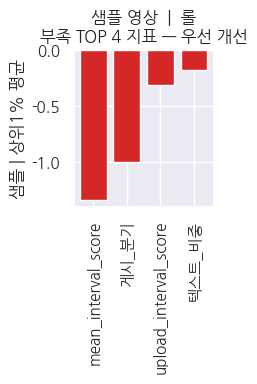

,샘플 영상,상위1% 영상
요일,토요일,화요일


In [18]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# 0) 수정할 부분
sample_idx = 5           # ← 업로드할 ‘샘플 영상’이 들어 있는 행 번호
top_pct    = 0.99        # 상위 몇 %를 비교 기준으로 할지 (0.90 = 상위 10 %)
top_n      = 8           # 그래프에 표시할 부족항목 개수

# 학습·분석 단계에서 사용했던 피처 전체
feature_cols = [
    '영상길이(초)','자막_topic_score','업로드_경과일','게시_분기',
    '텍스트_개수','텍스트_신뢰도','텍스트_비중',
    '얼굴_개수','얼굴_비중',
    '감정_angry','감정_disgust','감정_fear','감정_happy',
    '감정_sad','감정_surprise','감정_neutral',
    'upload_interval_score','mean_interval_score',
    '제목_평균조회수','제목_토픽_기반_예상조회수',
    '요일','시간대','주요_감정','얼굴_감지여부','챕터유무','URL_유무'
]

# ────────────────────────────────────────────────
df   = df.copy()                         # test_data + 파생 포함본
row  = df.loc[sample_idx]
gm   = row['게임명']
assert pd.notna(gm), "샘플 행에 게임명이 필요합니다!"

# 같은 게임의 상위 top_pct 풀
pool      = df[df['게임명']==gm]
top_pool  = pool[ pool['조회수'] >= pool['조회수'].quantile(top_pct) ]

numeric_cols = [c for c in feature_cols if c in df.columns and df[c].dtype.kind in 'fi']
cat_cols     = [c for c in feature_cols if c in df.columns and c not in numeric_cols]

# 1️⃣ 숫자형: 부족 항목 TOP n -------------------------------------------------
top_mean = top_pool[numeric_cols].mean(numeric_only=True)
diff     = (row[numeric_cols].astype(float) - top_mean).round(2)

# 부족(음수)만 추려 절댓값 큰 순
lack = diff[diff < 0].sort_values().head(top_n)

if not lack.empty:
    x = np.arange(len(lack))
    plt.figure(figsize=(len(lack)*0.6,4))
    plt.bar(x, lack, color='#d62728')
    plt.xticks(x, lack.index, rotation=90)
    plt.ylabel('샘플 | 상위1% 평균')
    plt.title(f"샘플 영상  |  {gm}\n부족 TOP {len(lack)} 지표 — 우선 개선")
    plt.tight_layout(); plt.show()
else:
    print("숫자형에서 부족(음수) 항목이 없습니다!")

# 2️⃣ 범주형: 샘플 ≠ 상위 모드 항목 ---------------------------------------
cat_sample = row[cat_cols]
cat_mode   = top_pool[cat_cols].mode(dropna=True).iloc[0] if not top_pool.empty else pd.Series(index=cat_cols)
diff_cat   = pd.DataFrame({
                '샘플 영상': cat_sample,
                '상위1% 영상': cat_mode
             })
diff_cat = diff_cat[diff_cat['샘플 영상'] != diff_cat['상위1% 영상']]

if not diff_cat.empty:
    display(diff_cat)
else:
    print("범주형에서도 샘플 값이 상위 모드와 모두 일치합니다!")
